# Visualizing Fixation Patterns

## The `FixationViewer`

```{admonition} Overview
The `FixationViewer` provides three visualizations:

- A playback of scanpath
- A fixation density map (i.e., heatmap)
- An areas-of-interest map

It also shows some basic fixation measures, such as fixation count and duration.

`FixationViewer` should come in handy when you want to get a first impression of eye movement patterns during a particular trial.
```

To demonstrate how `FixationViewer` works, let's first generate some fake data:

In [41]:
import numpy as np
import pandas as pd
import pupeyes as pe

%load_ext autoreload
%autoreload 2

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


In [42]:
# generate some fake fixation data
screen_dims = (1600, 1200) # width, height
pics = ['street1.jpg', 'street2.jpg']
x = np.random.randint(0, screen_dims[0], size=100)
y = np.random.randint(0, screen_dims[1], size=100)
duration = np.random.randint(100, 1000, size=100)
stimuli = ['street1.jpg'] * 50 + ['street2.jpg'] * 50
trial_id = [1] * 50 + [2] * 50

fixation_data = pd.DataFrame({'x': x, 'y': y, 'duration': duration, 'stimuli': stimuli, 'trial_id': trial_id})
fixation_data

,x,y,duration,stimuli,trial_id
0,28,574,337,street1.jpg,1
1,80,299,934,street1.jpg,1
2,937,1194,214,street1.jpg,1
3,828,153,361,street1.jpg,1
4,1096,155,145,street1.jpg,1
...,...,...,...,...,...
95,735,717,311,street2.jpg,2
96,1246,449,431,street2.jpg,2
97,882,46,687,street2.jpg,2
98,1423,814,735,street2.jpg,2


The fake data consists of 2 trials, with each trial including 50 fixations on the associated stimulus.

I also defined my areas of interest for my stimuli [using the `AOIDrawer` tool](aoi_analysis.ipynb). So I will load those `.json` files and format the AOIs in a way that's supported by `FixationViewer`. 

In [43]:
import json

# load AOIs
with open('assets/street1_aois.json', 'r') as f:
    aois1 = json.load(f)

with open('assets/street2_aois.json', 'r') as f:
    aois2 = json.load(f)

# nested dictionary
aois = {
    'street1.jpg': aois1, # key is the stimulus name in the data
    'street2.jpg': aois2
}

The next step is to initialize `FixationViewer` by passing the correct arguments. 

In [44]:
from pupeyes import FixationViewer

# path that stores my stimulus pictures
pic_path = 'assets/'

# Create visualizer
viz = FixationViewer(
    data=fixation_data,  # your fixation dataframe
    screen_dims = (1600, 1200),
    stimuli_path = pic_path,
    col_mapping={
        'trial_id': 'trial_id',  # List of columns that identify a trial
        'x': 'x',  # x coordinate column name
        'y': 'y',  # y coordinate column name
        'duration': 'duration',  # duration column name
        'stimuli': 'stimuli'  # uncomment if you have stimuli images
    }
)

# Set AOIs if needed
viz.set_aois(aois)

No timestamp column specified.


```{note}
The timestamp and duration columns are optional. Some measures will not be displayed, however.
```

Then, let's run it!

In [45]:
# Run the server
viz.run(port=8020)

Original size: (6231, 4154) Resized size: (1600, 1200)
Original size: (6231, 4154) Resized size: (1600, 1200)
Original size: (6231, 4154) Resized size: (1600, 1200)


## Static Drawing Tools

PupEyes also provides several static drawing options using `matplotlib`.

### Scanpaths

Original size: (6231, 4154) Resized size: (1600, 1200)


(<Figure size 640x480 with 2 Axes>, <Axes: title={'center': 'Scanpath'}>)

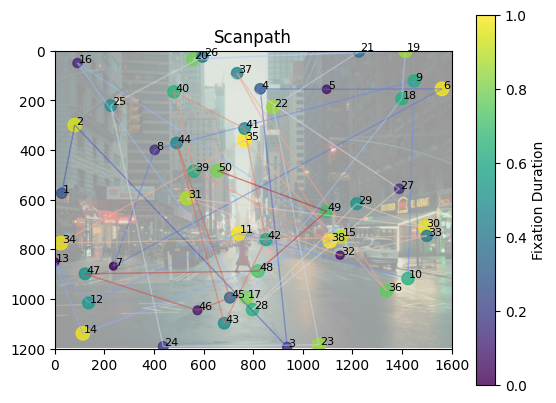

In [46]:
from pupeyes import draw_scanpath

plot_data = fixation_data.query('trial_id==1')
path = 'assets/street1.jpg'

draw_scanpath(x=plot_data['x'], y=plot_data['y'], screen_dims=(1600, 1200), durations=plot_data['duration'], background_img=path)

### Drawing Heatmap

Original size: (6231, 4154) Resized size: (1600, 1200)


(<Figure size 640x480 with 2 Axes>,
 <Axes: title={'center': 'Fixation Density Heatmap'}>)

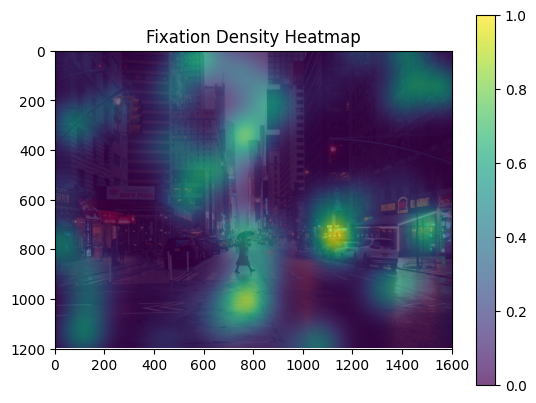

In [47]:
from pupeyes import draw_heatmap

draw_heatmap(x=plot_data['x'], y=plot_data['y'], screen_dims=(1600, 1200), durations=plot_data['duration'], background_img=path)

### Draw AOIs

Original size: (6231, 4154) Resized size: (1600, 1200)


(<Figure size 640x480 with 1 Axes>,
 <Axes: title={'center': 'Areas of Interest (AOIs)'}>)

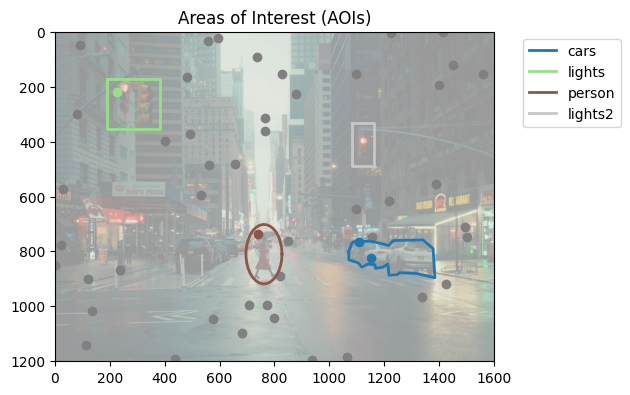

In [50]:
from pupeyes import draw_aois

draw_aois(aois=aois1, x=plot_data['x'], y=plot_data['y'], screen_dims=(1600, 1200), background_img=path)